In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive/')
PROJECT_DIR = "/content/drive/MyDrive/aptos_project"
DATA_DIR = f"{PROJECT_DIR}/data"
os.makedirs(PROJECT_DIR, exist_ok=True)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
# Import model

import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 5)  ## Change for multi class

# Change to final model path
model.load_state_dict(torch.load(
    "/content/drive/MyDrive/aptos_project/models/model_weights.pth",
    map_location=device
))
model = model.to(device)
model.eval()

print("Model loaded successfully!")

Using device: cpu
Model loaded successfully!


In [ ]:
# Import Data
import pandas as pd
import os

train_df = pd.read_csv(f"{DATA_DIR}/train.csv")

print(train_df.head())
print(train_df.columns)
print(train_df.shape)


        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0
Index(['id_code', 'diagnosis'], dtype='object')
(3662, 2)


In [ ]:
# Same split

from sklearn.model_selection import train_test_split

train_val_df, test_data = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["diagnosis"],
    random_state=42
)

train_data, val_data = train_test_split(
    train_val_df,
    test_size=0.2,
    stratify=train_val_df["diagnosis"],
    random_state=42
)

train_data.shape, val_data.shape, test_data.shape

((2343, 2), (586, 2), (733, 2))

In [ ]:
# Nonmember/member split
member_df = train_data.copy()

# Nonmember includes both val/test
nonmember_df = pd.concat(
    [val_data, test_data],
    ignore_index=True
)

print("Member/train data:", member_df.shape)
print(member_df["diagnosis"].value_counts())

print("\nNonmember/val+test data:", nonmember_df.shape)
print(nonmember_df["diagnosis"].value_counts())

Member/train data: (2343, 2)
diagnosis
0    1155
2     639
1     237
4     189
3     123
Name: count, dtype: int64

Nonmember/val+test data: (1319, 2)
diagnosis
0    650
2    360
1    133
4    106
3     70
Name: count, dtype: int64


In [ ]:
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
import cv2
import numpy as np

def crop_retina(im, tol=20, pad=10):
    im = im.convert("RGB")
    arr = np.array(im)

    gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)

    mask = gray > tol

    if not mask.any():
        return im

    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    y0 = max(y0 - pad, 0)
    x0 = max(x0 - pad, 0)
    y1 = min(y1 + pad, arr.shape[0])
    x1 = min(x1 + pad, arr.shape[1])

    cropped = im.crop((x0, y0, x1, y1))

    return cropped

class APTOSDataset(Dataset):
    def __init__(self, dataframe, img_dir, label_col):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.label_col = label_col

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_id = self.dataframe.loc[idx, "id_code"]
        img_path = os.path.join(self.img_dir, img_id + ".png")
        image = Image.open(img_path).convert("RGB")

        image = crop_retina(image, tol=20, pad=10)
        label = int(self.dataframe.loc[idx, self.label_col])

        return image, label

IMG_DIR = f"{DATA_DIR}/train_images"
member_dataset = APTOSDataset(member_df, IMG_DIR, label_col="diagnosis")
nonmember_dataset = APTOSDataset(nonmember_df, IMG_DIR, label_col="diagnosis")

print("Member dataset length:", len(member_dataset))
print("Nonmember dataset length:", len(nonmember_dataset))

Member dataset length: 2343
Nonmember dataset length: 1319


In [ ]:
from torchvision import transforms

mc_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    # small random changes for Monte Carlo trials
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),

    transforms.ToTensor(),

    # ImageNet normalization because ResNet18 was pretrained on ImageNet
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Monte Carlo transform ready.")

Monte Carlo transform ready.


In [ ]:
# MONTECARLO TRANSFORMATIONS
from torchvision import transforms

mc_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    # small random changes for Monte Carlo trials
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),

    transforms.ToTensor(),

    # ImageNet normalization because ResNet18 was pretrained on ImageNet
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
image, label = member_dataset[0]

aug_img = mc_transform(image)

print(type(aug_img))
print(aug_img.shape)
print(label)

<class 'torch.Tensor'>
torch.Size([3, 224, 224])
0


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np

def monte_carlo_features(model, image, label, mc_transform, device, T=30):
    model.eval()

    probs_list = []
    losses = []

    y = torch.tensor([label], dtype=torch.long).to(device)

    with torch.no_grad():
        for _ in range(T):
            aug_img = mc_transform(image).unsqueeze(0).to(device)

            logits = model(aug_img)
            probs = F.softmax(logits, dim=1)

            loss = F.cross_entropy(logits, y, reduction="none")

            probs_list.append(probs.cpu().numpy()[0])
            losses.append(loss.item())

    probs_array = np.array(probs_list)
    losses = np.array(losses)

    true_class_probs = probs_array[:, label]
    entropies = -np.sum(probs_array * np.log(probs_array + 1e-12), axis=1)

    features = {
        "mean_true_conf": true_class_probs.mean(),
        "std_true_conf": true_class_probs.std(),
        "mean_entropy": entropies.mean(),
        "std_entropy": entropies.std(),
        "mean_loss": losses.mean(),
        "std_loss": losses.std(),
    }

    return features

In [ ]:
# Testing membership data
image, label = member_dataset[0]

features = monte_carlo_features(
    model=model,
    image=image,
    label=label,
    mc_transform=mc_transform,
    device=device,
    T=10
)

features

{'mean_true_conf': np.float32(0.9120785),
 'std_true_conf': np.float32(0.01958574),
 'mean_entropy': np.float32(0.3918038),
 'std_entropy': np.float32(0.06701482),
 'mean_loss': np.float64(0.09226299673318863),
 'std_loss': np.float64(0.02169519583855968)}

In [ ]:
# Testing nonmembership data
image, label = nonmember_dataset[0]

features = monte_carlo_features(
    model=model,
    image=image,
    label=label,
    mc_transform=mc_transform,
    device=device,
    T=10
)

features

{'mean_true_conf': np.float32(0.11356405),
 'std_true_conf': np.float32(0.017852541),
 'mean_entropy': np.float32(0.661),
 'std_entropy': np.float32(0.071090035),
 'mean_loss': np.float64(2.1878551244735718),
 'std_loss': np.float64(0.158401386124879)}

In [ ]:
from tqdm.notebook import tqdm

def extract_attack_dataset(model, dataset, mc_transform, device, is_member, T=20, max_samples=50):
  rows = []
  n = len(dataset) if max_samples is None else max_samples

  for i in tqdm(range(n)):
    image, label = dataset[i]

    features = monte_carlo_features(
      model=model,
      image=image,
      label=label,
      mc_transform=mc_transform,
      device=device,
      T=T
    )

    # Store label and memebrship label

    features["true label"] = label
    features["member"] = int(is_member)

    rows.append(features)

  return pd.DataFrame(rows)


In [ ]:
# Create attack dataset for nonmember and member
member_features = extract_attack_dataset(
    model=model,
    dataset=member_dataset,
    mc_transform=mc_transform,
    device=device,
    is_member=True,
    T=10,
    max_samples=100
)

nonmember_features = extract_attack_dataset(
    model=model,
    dataset=nonmember_dataset,
    mc_transform=mc_transform,
    device=device,
    is_member=False,
    T=10,
    max_samples=100
)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
attack_df = pd.concat(
    [member_features, nonmember_features],
    ignore_index=True
)

print(attack_df.head())
print("\nMembership counts:")
print(attack_df["member"].value_counts())

   mean_true_conf  std_true_conf  mean_entropy  std_entropy  mean_loss  \
0        0.908620       0.015882      0.404205     0.053287   0.095983   
1        0.941813       0.014977      0.280688     0.056642   0.060076   
2        0.929477       0.009439      0.326638     0.032378   0.073185   
3        0.201675       0.022107      1.226309     0.045482   1.606885   
4        0.944942       0.003659      0.271946     0.014998   0.056639   

   std_loss  true label  member  
0  0.017574           0       1  
1  0.016043           0       1  
2  0.010190           0       1  
3  0.106684           4       1  
4  0.003874           0       1  

Membership counts:
member
1    100
0    100
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

feature_cols = [
    "mean_true_conf",
    "std_true_conf",
    "mean_entropy",
    "std_entropy",
    "mean_loss",
    "std_loss"
]

# X = behavior features
X = attack_df[feature_cols]

# y = membership label: 1 = train member, 0 = nonmember
y = attack_df["member"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Train simple attack classifier
attack_model = LogisticRegression(max_iter=1000)
attack_model.fit(X_train, y_train)

# Predict membership on held-out attack test set
attack_preds = attack_model.predict(X_test)

# Probability that each row is a member
attack_probs = attack_model.predict_proba(X_test)[:, 1]

# Evaluate attack
print("Attack Accuracy:", accuracy_score(y_test, attack_preds))
print("Attack AUC:", roc_auc_score(y_test, attack_probs))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, attack_preds))

print("\nClassification Report:")
print(classification_report(y_test, attack_preds))

Attack Accuracy: 0.5666666666666667
Attack AUC: 0.6188888888888888

Confusion Matrix:
[[16 14]
 [12 18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.53      0.55        30
           1       0.56      0.60      0.58        30

    accuracy                           0.57        60
   macro avg       0.57      0.57      0.57        60
weighted avg       0.57      0.57      0.57        60



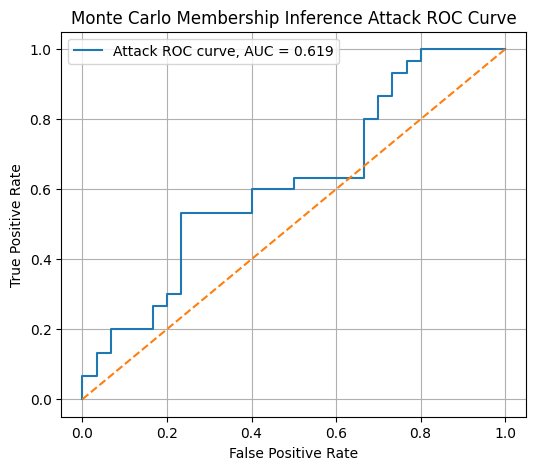

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, attack_probs)
attack_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Attack ROC curve, AUC = {attack_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Monte Carlo Membership Inference Attack ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

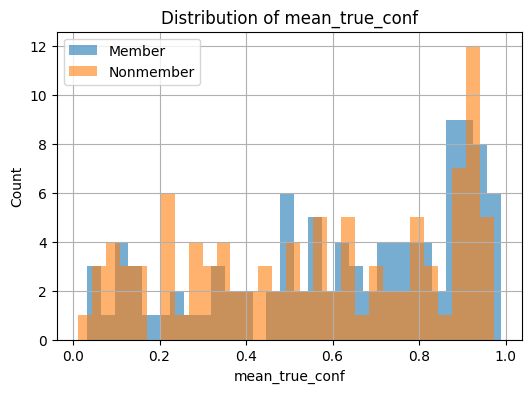

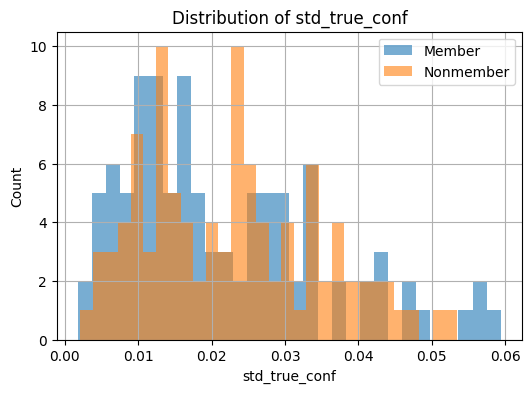

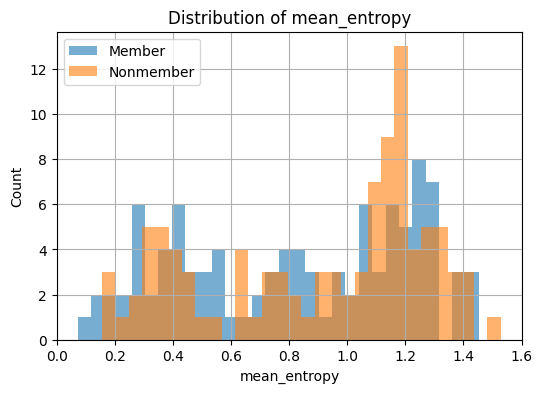

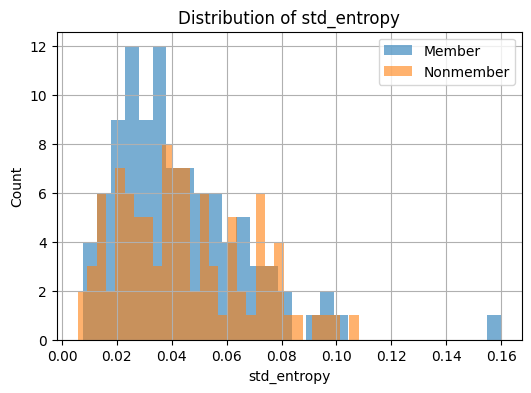

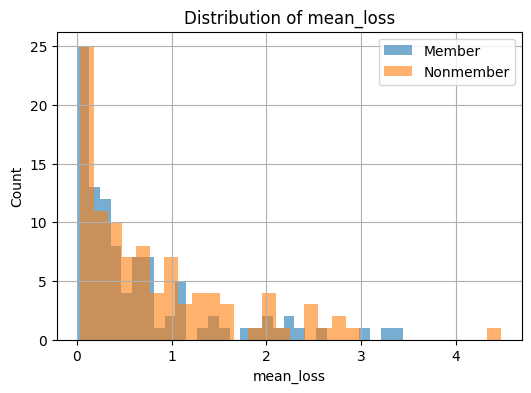

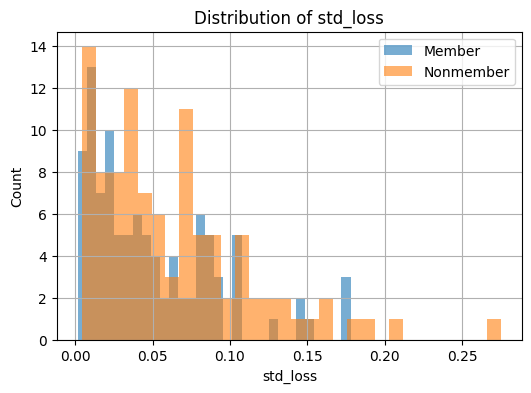

In [ ]:
import matplotlib.pyplot as plt

feature_cols = [
    "mean_true_conf",
    "std_true_conf",
    "mean_entropy",
    "std_entropy",
    "mean_loss",
    "std_loss"
]

for col in feature_cols:
    plt.figure(figsize=(6, 4))

    plt.hist(
        attack_df[attack_df["member"] == 1][col],
        alpha=0.6,
        label="Member",
        bins=30
    )

    plt.hist(
        attack_df[attack_df["member"] == 0][col],
        alpha=0.6,
        label="Nonmember",
        bins=30
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# Examples for slides

Label: 1


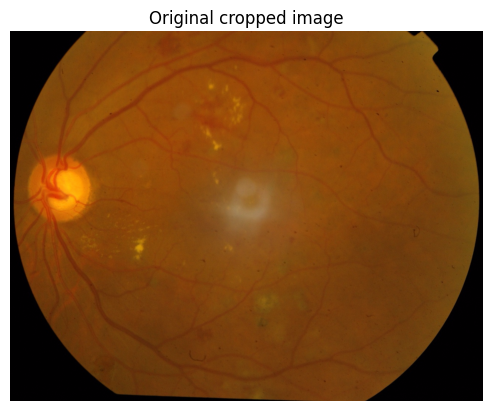

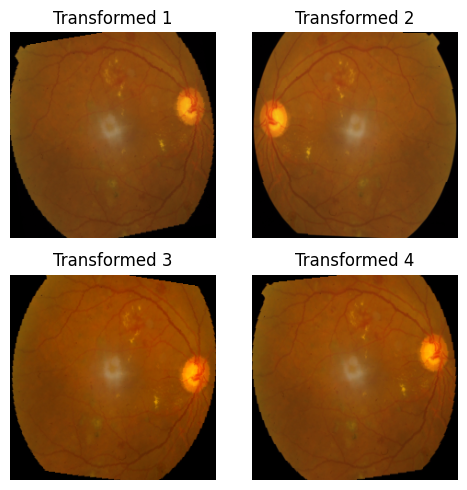

In [ ]:
import matplotlib.pyplot as plt
import torch

# Helper to undo ImageNet normalization so matplotlib can display it
def unnormalize_img(tensor_img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    tensor_img = tensor_img.cpu() * std + mean
    tensor_img = torch.clamp(tensor_img, 0, 1)

    return tensor_img.permute(1, 2, 0)  # [C,H,W] -> [H,W,C]


# Pick one image from your member dataset
image, label = member_dataset[0]

print("Label:", label)

# Show original cropped PIL image
plt.imshow(image)
plt.title("Original cropped image")
plt.axis("off")
plt.show()

fig, axes = plt.subplots(2,2, figsize=(5,5))
# Show 5 randomly transformed versions
for i, ax in enumerate(axes.flatten()):
    transformed = mc_transform(image)
    display_img = unnormalize_img(transformed)

    ax.imshow(display_img)
    ax.set_title(f"Transformed {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()